In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [2]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]

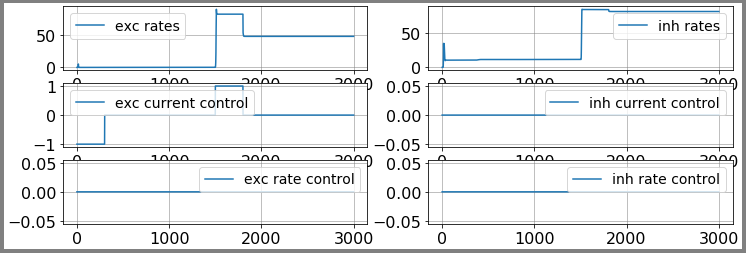

[[47.5098 82.4113]
 [ 0.0825 11.6383]]


In [3]:
aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 2.

aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.

aln.params.sigmae_ext = 0.5
aln.params.sigmai_ext = 0.5

# NO ADAPTATION
aln.params.a = 0.
aln.params.b = 0.

plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = aln.rates_exc[0,-1] # high state exc
steady_rates[0,1] = aln.rates_inh[0,-1] # high state inh
steady_rates[1,0] = aln.rates_exc[0,14500] # low state exc
steady_rates[1,1] = aln.rates_inh[0,14500] # low state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0] 
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]

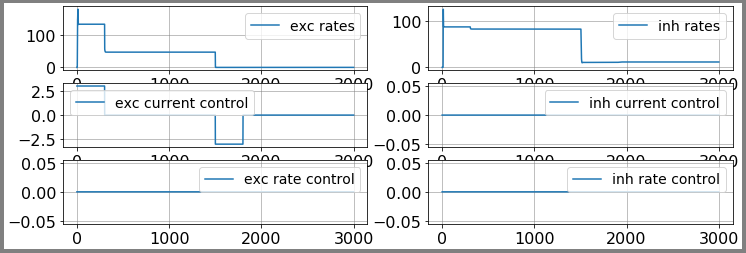

low state vars =  [ 8.2469e-02  1.1638e+01  4.3314e-01  7.5957e-01  0.0000e+00  1.6029e-02
  6.3812e-01  1.4997e-02  7.8014e-01  9.5893e-04  6.6523e-03  8.4016e-04
  6.5247e-03  0.0000e+00  0.0000e+00  7.1463e-01  5.5403e-01 -5.6298e+01
  2.7100e+01  6.3823e+00]


In [4]:
control0 = step_control(maxI_ = -3.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]

print("low state vars = ", low_state_vars)

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [5]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 5000

initVars = low_state_vars

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 
                    0.8, 0.8, 0.8, 0.8, 0.8 ]

sheet = "A"

target_rates = np.array( [steady_rates[0,0], steady_rates[0,1]])

In [6]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

## 1

set cost params
control input:  [1] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  1114.7772271219046
RUN  2 , total integrated cost =  64.36350230942439
RUN  3 , total integrated cost =  4.146698892351714
RUN  4 , total integrated cost =  0.8008578183467647
RUN  5 , total integrated cost =  0.2637191439959953
RUN  6 , total integrated cost =  0.11787604894547563
RUN  7 , total integrated cost =  0.0623530755405265
RUN  8 , total integrated cost =  0.03741003355062241
RUN  9 , total integrated cost =  0.024251026637931827
RUN  10 , total integrated cost =  0.01663830509607956
RUN  11 , total integrated cost =  0.011927743230524927
RUN  12 , total integrated cost =  0.008948469285563046
RUN  13 , total integrated cost =  0.0069249796097096555
RUN  14 , total integrated cost =  0.005475583110477453
RUN  15 , total integrated cost =  0.004410975129854733
RUN  16 , total integrated cost = 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  856 , total integrated cost =  3.150394911090648e-26
Improved over  856  iterations by  100.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.17462426514522 -56.17462318004812


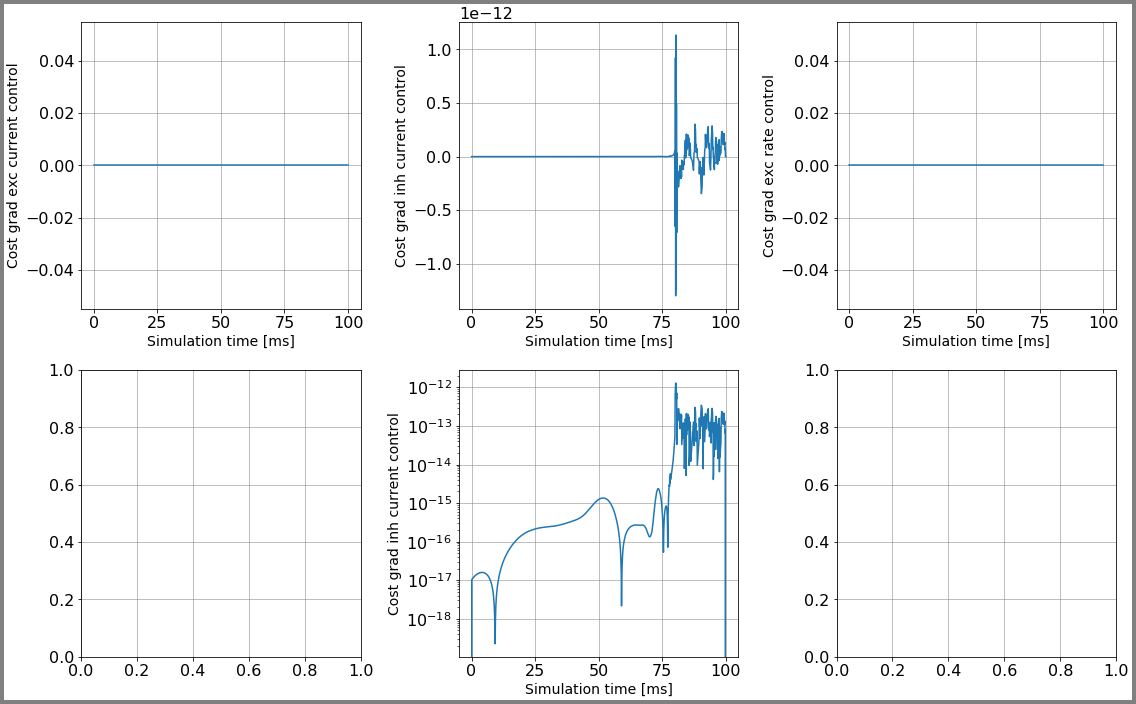

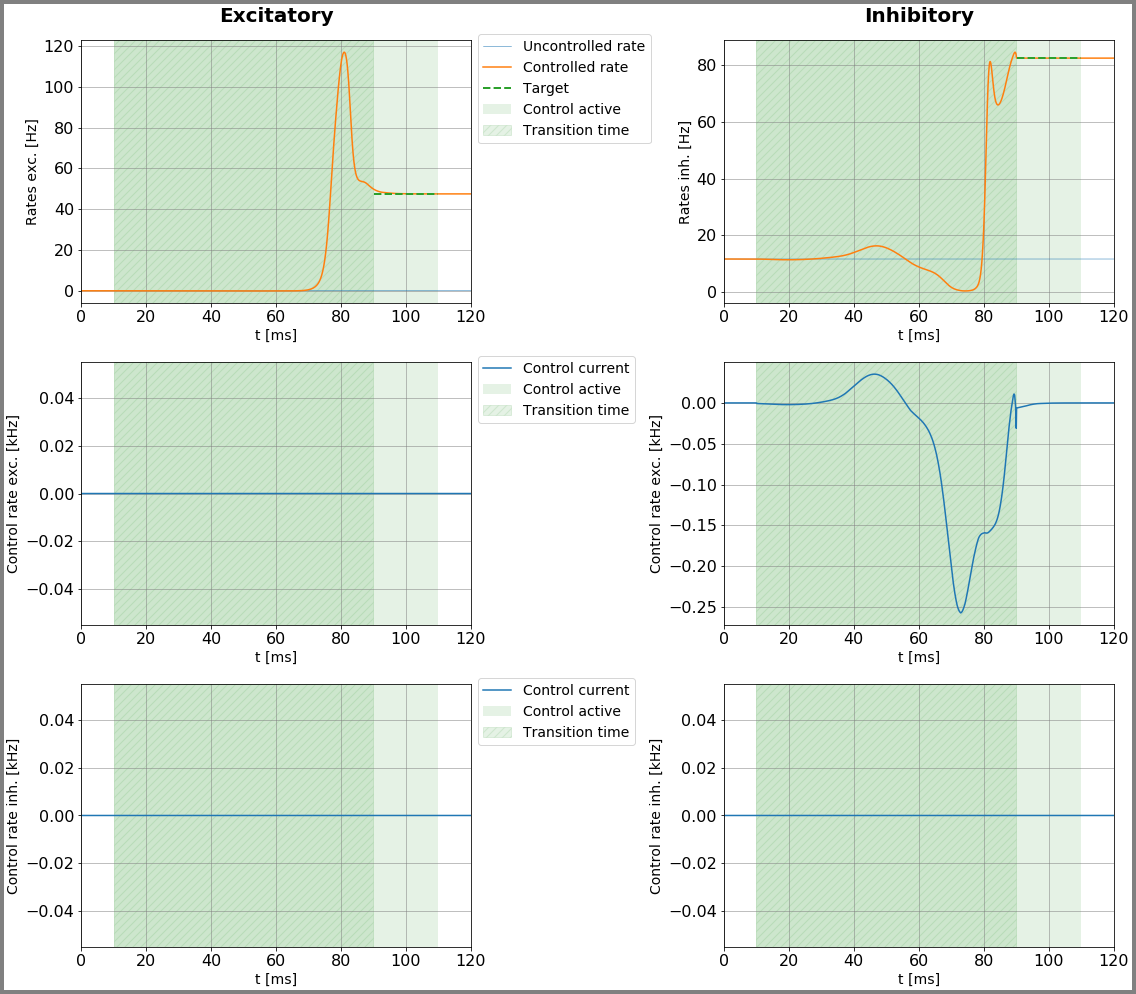

In [7]:
# B.0.a)

dur = 100
dur_pre = 10
dur_post = 10
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

# set low state rates as target
target = aln.getZeroTarget()
target[:,0,:] = target_rates[0]
target[:,1,:] = target_rates[1]

case_ind = 1
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  1271.5911230267923
RUN  2 , total integrated cost =  526.2817261158461
RUN  3 , total integrated cost =  263.4876798601083
RUN  4 , total integrated cost =  192.7081381452777
RUN  5 , total integrated cost =  140.36035282279016
RUN  6 , total integrated cost =  109.91978394384883
RUN  7 , total integrated cost =  84.61449889520345
RUN  8 , total integrated cost =  64.26506828460825
RUN  9 , total integrated cost =  49.69781531442278
RUN  10 , total integrated cost =  43.1601995319455
RUN  11 , total integrated cost =  40.70117213293534
RUN  12 , total integrated cost =  39.07561034707648
RUN  13 , total integrated cost =  37.98227065726353
RUN  14 , total integrated cost =  36.96653713258911
RUN  15 , total integrated cost =  36.27792842900034
RUN  16 , total integrated cost =  35.598178017113334
RUN  17 , total integrated cost =  35.07417677618326


ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  14.817991683535714
RUN  5000 , total integrated cost =  14.817991683535714
Improved over  5000  iterations by  99.97041619901822  percent.
Problem in initial value trasfer:  Vmean_exc -56.17458193844778 -56.17458225177083


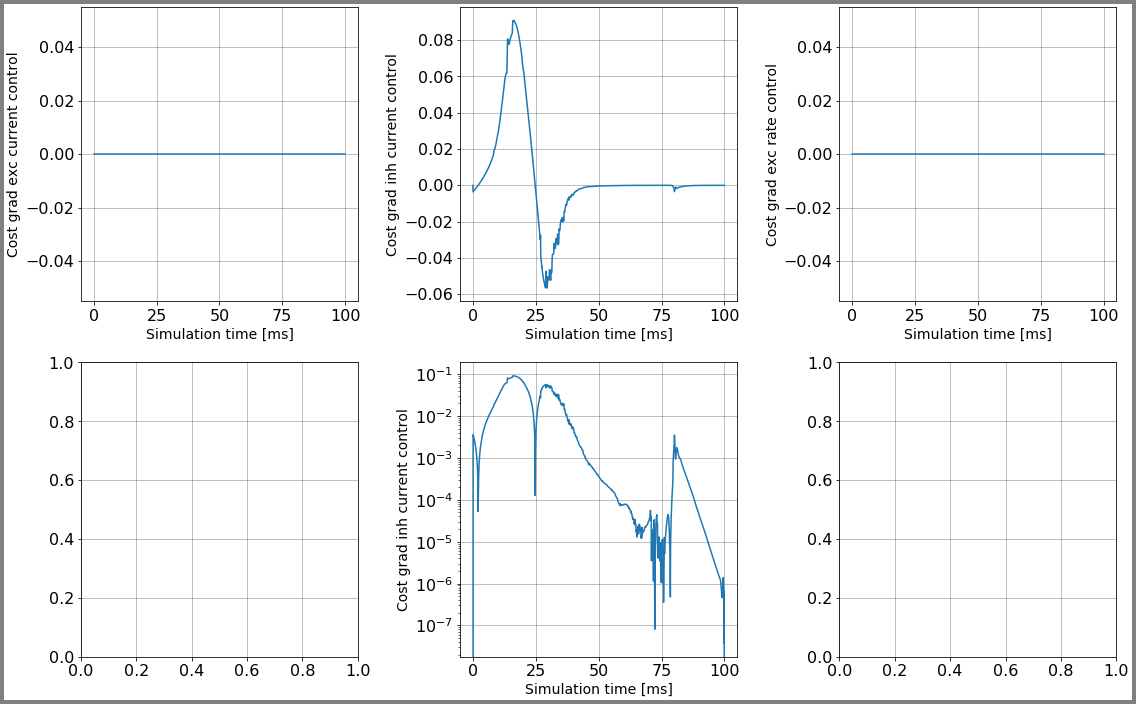

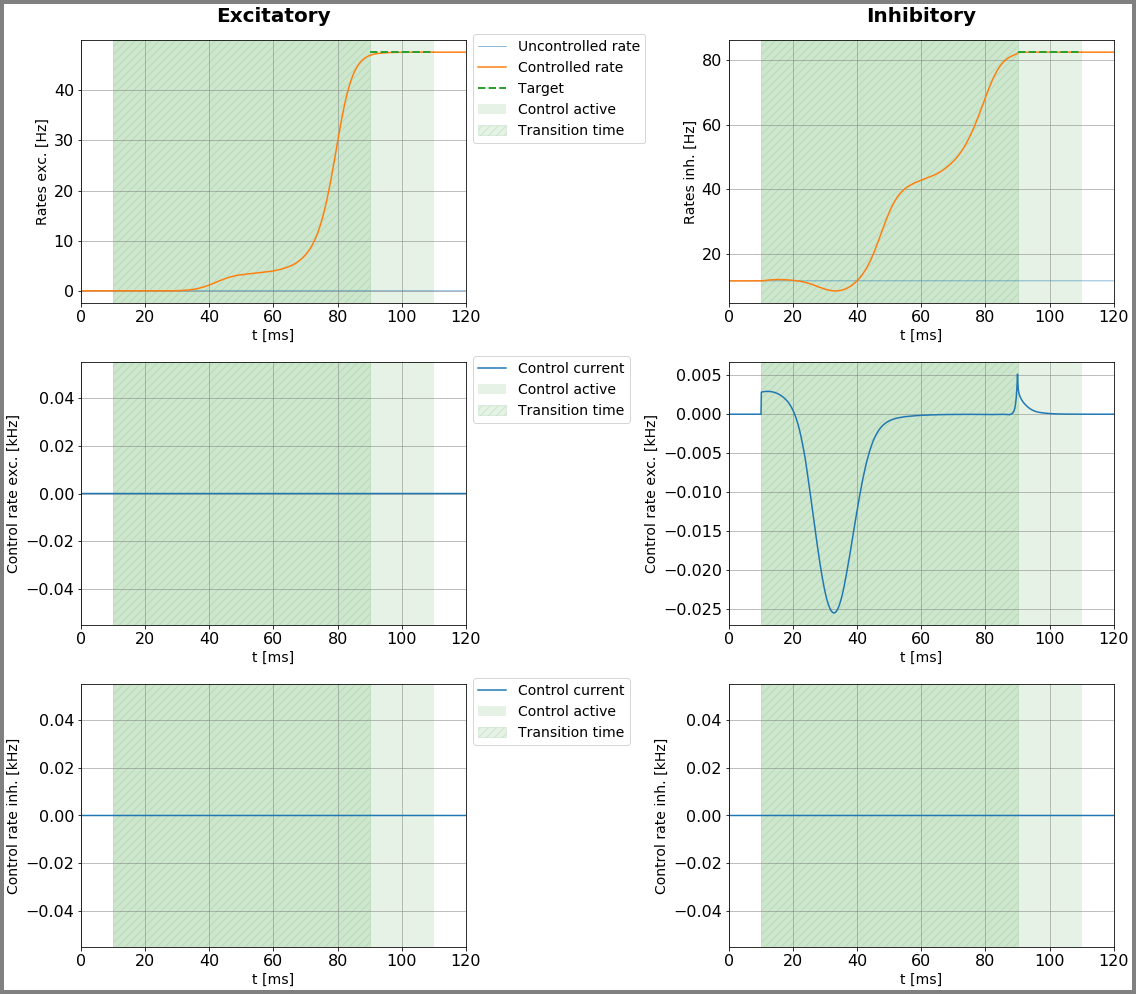

In [8]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 1
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 3

set cost params
control input:  [0] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  26.719456554758978
RUN  2 , total integrated cost =  12.008325613115135
RUN  3 , total integrated cost =  5.870992008974145
RUN  4 , total integrated cost =  3.238704212455777
RUN  5 , total integrated cost =  2.3042150441257863
RUN  6 , total integrated cost =  1.6433523795740912
RUN  7 , total integrated cost =  1.2274317193943418
RUN  8 , total integrated cost =  0.9440012777867578
RUN  9 , total integrated cost =  0.7509429689935456
RUN  10 , total integrated cost =  0.609536273151728
RUN  11 , total integrated cost =  0.5042680468641128
RUN  12 , total integrated cost =  0.42112619354487946
RUN  13 , total integrated cost =  0.3612949685627454
RUN  14 , total integrated cost =  0.3103124509452297
RUN  15 , total integrated cost =  0.27007567020893747
RUN  16 , total integrated cost =  0.238644877862

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  5.769173276729952e-05
RUN  5000 , total integrated cost =  5.769173276729952e-05
Improved over  5000  iterations by  99.9999998848197  percent.
Problem in initial value trasfer:  Vmean_exc -56.17459116312255 -56.17459117822872


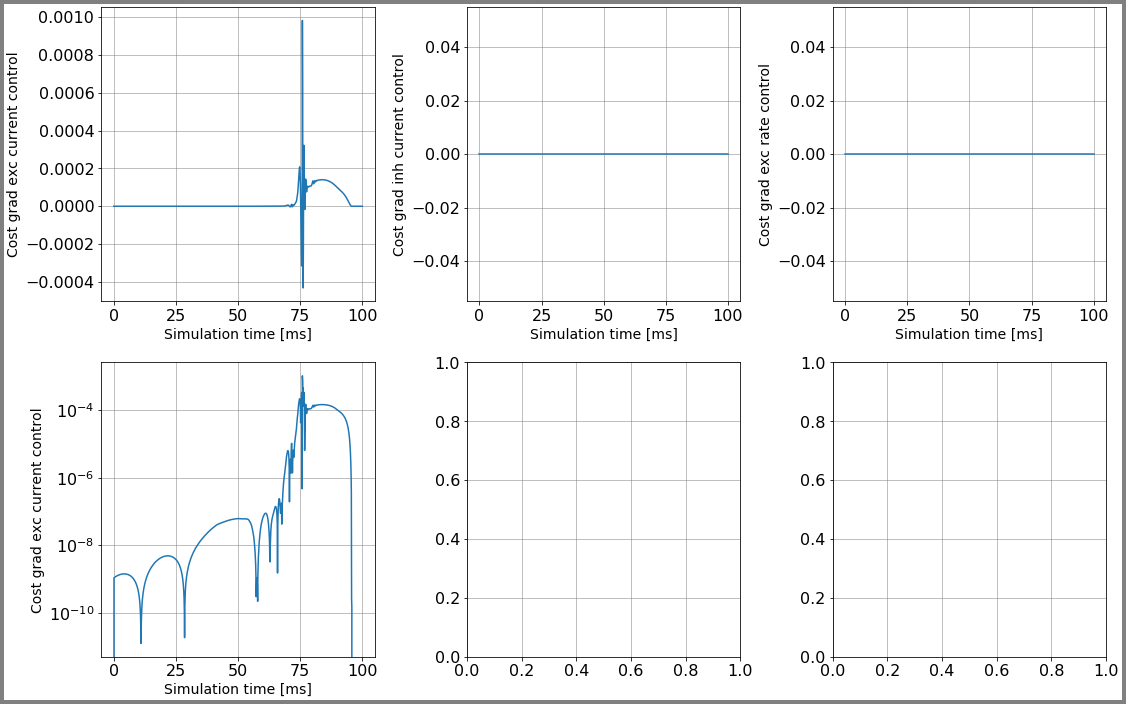

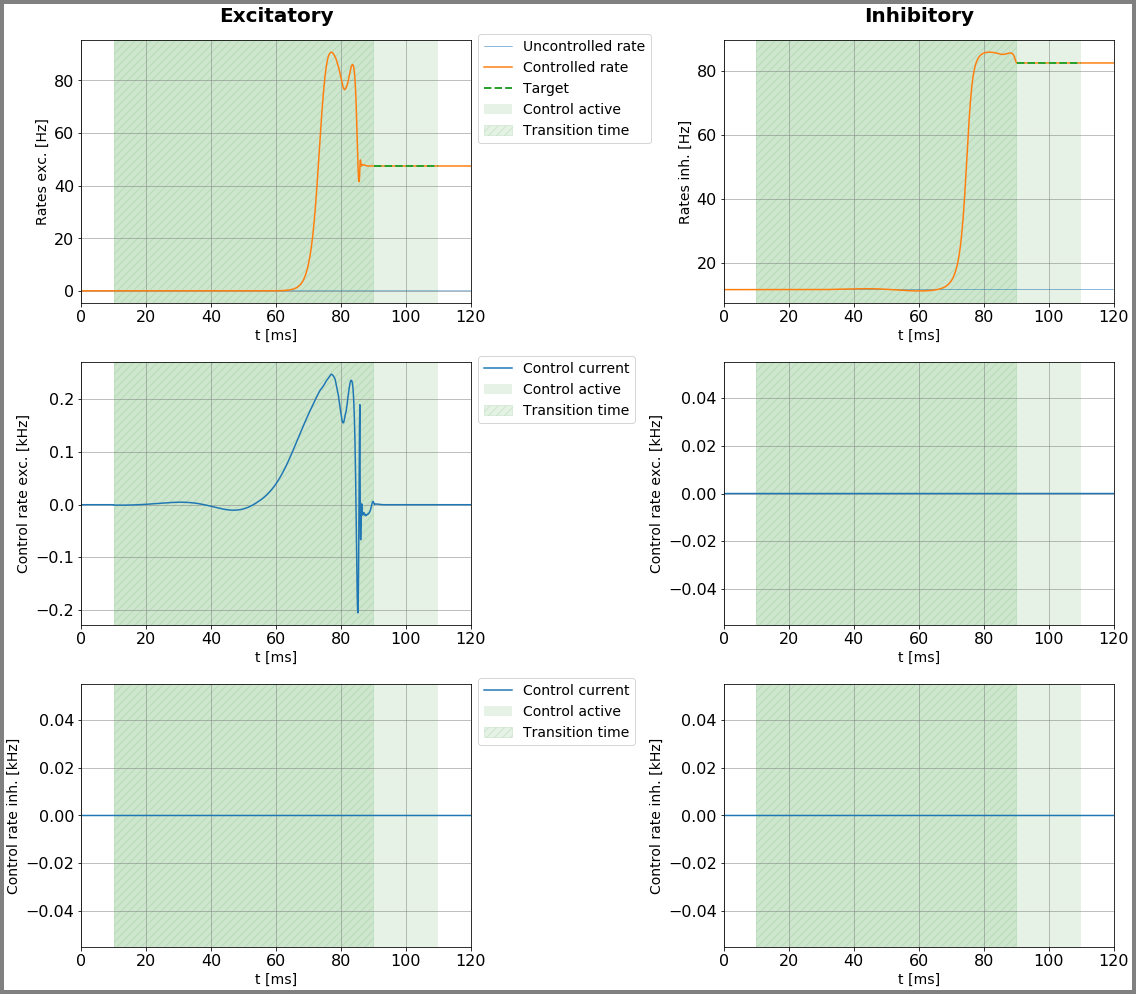

In [9]:
case_ind = 3
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  224.8994790781823
RUN  2 , total integrated cost =  207.6169584283215
RUN  3 , total integrated cost =  177.75775232822576
RUN  4 , total integrated cost =  165.1996202400153
RUN  5 , total integrated cost =  145.2172191752332
RUN  6 , total integrated cost =  135.9074394642475
RUN  7 , total integrated cost =  122.4813975771038
RUN  8 , total integrated cost =  115.4271321123286
RUN  9 , total integrated cost =  105.33909610856404
RUN  10 , total integrated cost =  100.04494064989328
RUN  11 , total integrated cost =  93.07805719753958
RUN  12 , total integrated cost =  89.06588434694713
RUN  13 , total integrated cost =  83.34027665955502
RUN  14 , total integrated cost =  79.89275255715313
RUN  15 , total integrated cost =  75.60824677668188
RUN  16 , total integrated cost =  73.11289284429022
RUN  17 , total integrated cost =  69.52921340154893


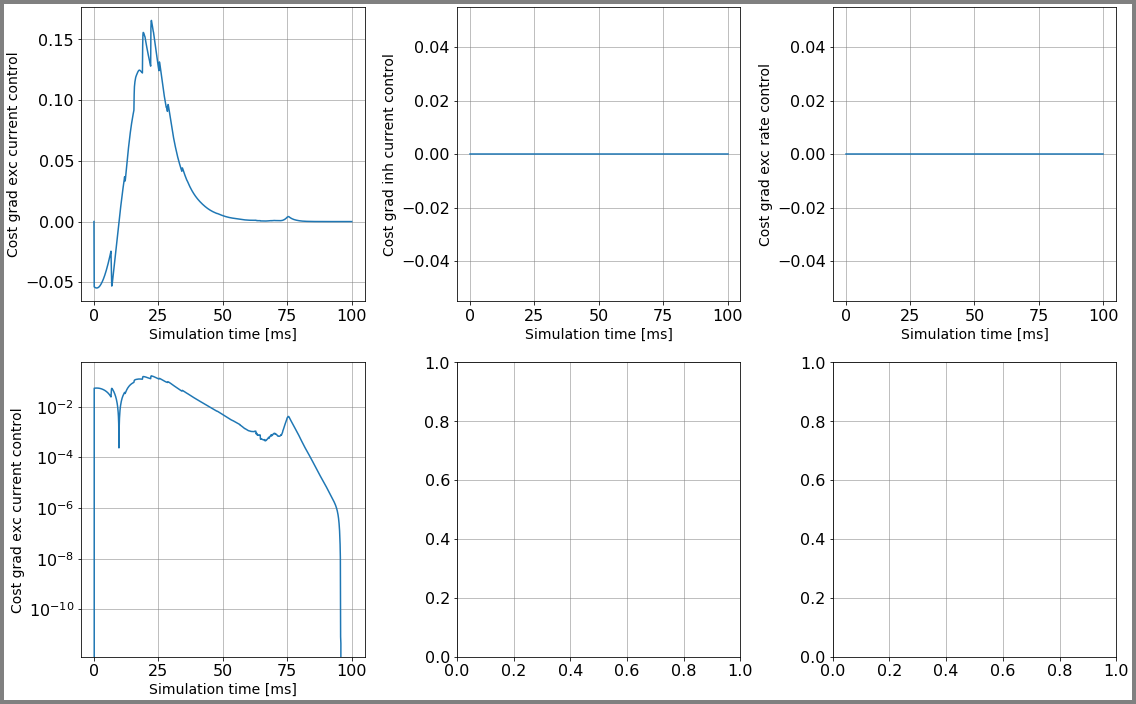

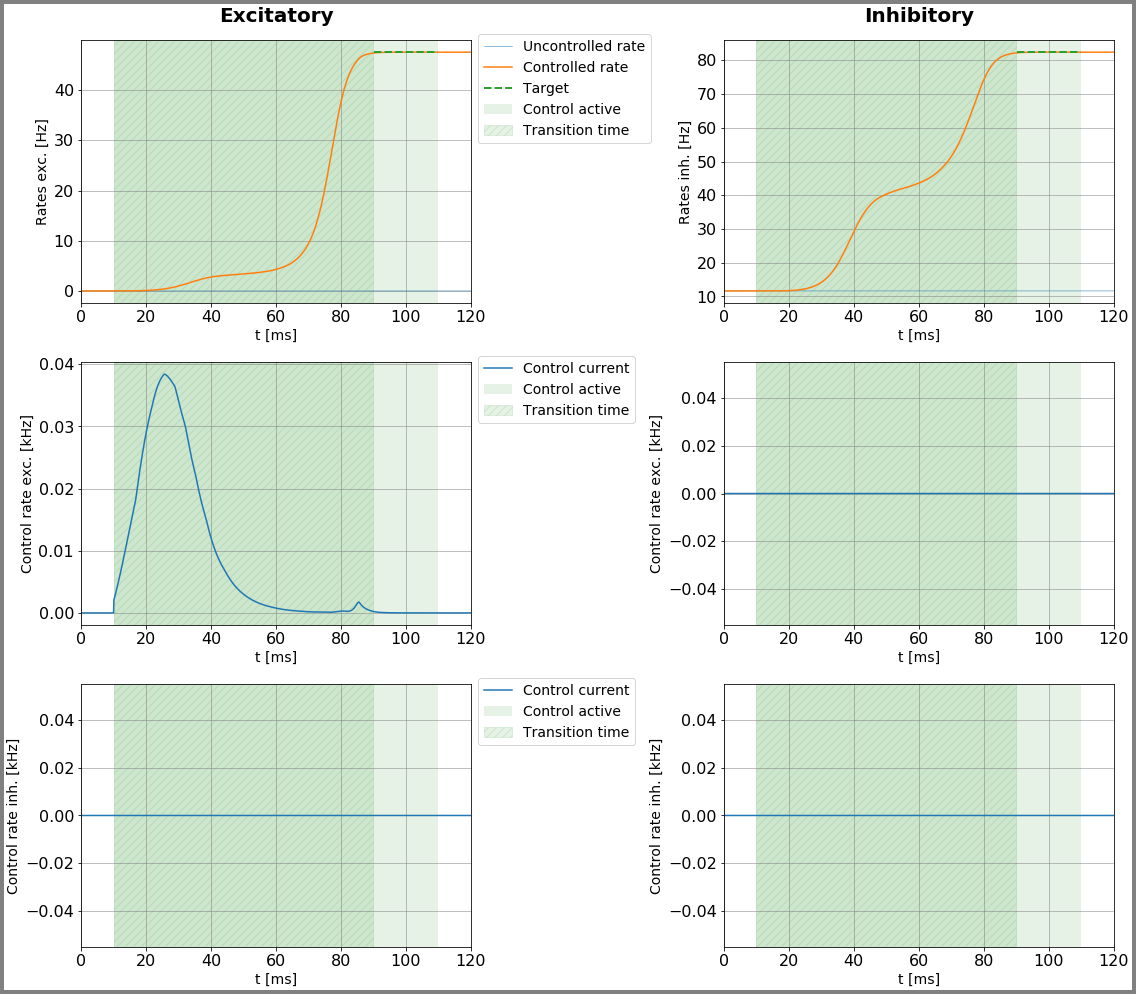

In [10]:
case_ind = 3
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 5

set cost params
control input:  [2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  3.031024186152988
RUN  2 , total integrated cost =  0.6277999244281951
RUN  3 , total integrated cost =  0.00022455396128151232
RUN  4 , total integrated cost =  1.016598951447004e-07
RUN  5 , total integrated cost =  3.842831545759916e-11
RUN  6 , total integrated cost =  1.8443773619955997e-13
RUN  7 , total integrated cost =  8.956748574818431e-17
RUN  8 , total integrated cost =  4.416969685911806e-19
RUN  9 , total integrated cost =  3.924584164677787e-22
RUN  10 , total integrated cost =  9.017919604930446e-23
RUN  11 , total integrated cost =  5.299433770465231e-23
RUN  12 , total integrated cost =  1.5058453485970992e-23
RUN  13 , total integrated cost =  1.2379436413452285e-25
RUN  14 , total integrated cost =  1.1073840060875327e-25
RUN  15 , total integrated cost =  1.0737595988633917e-25
RUN 

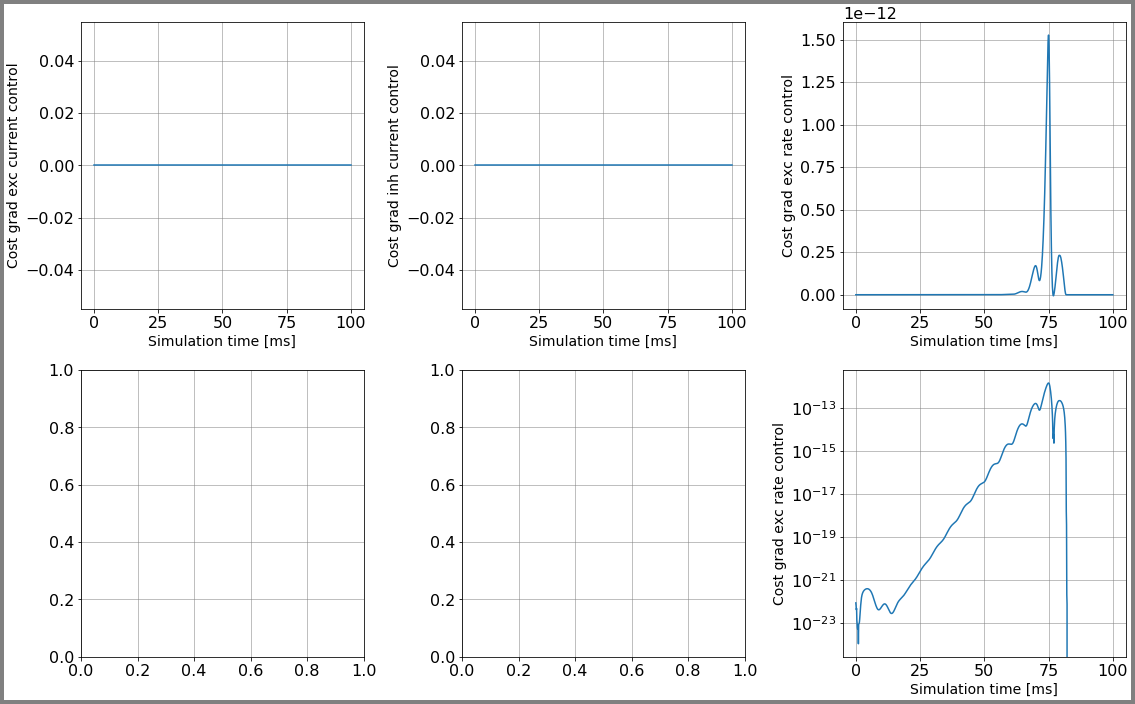

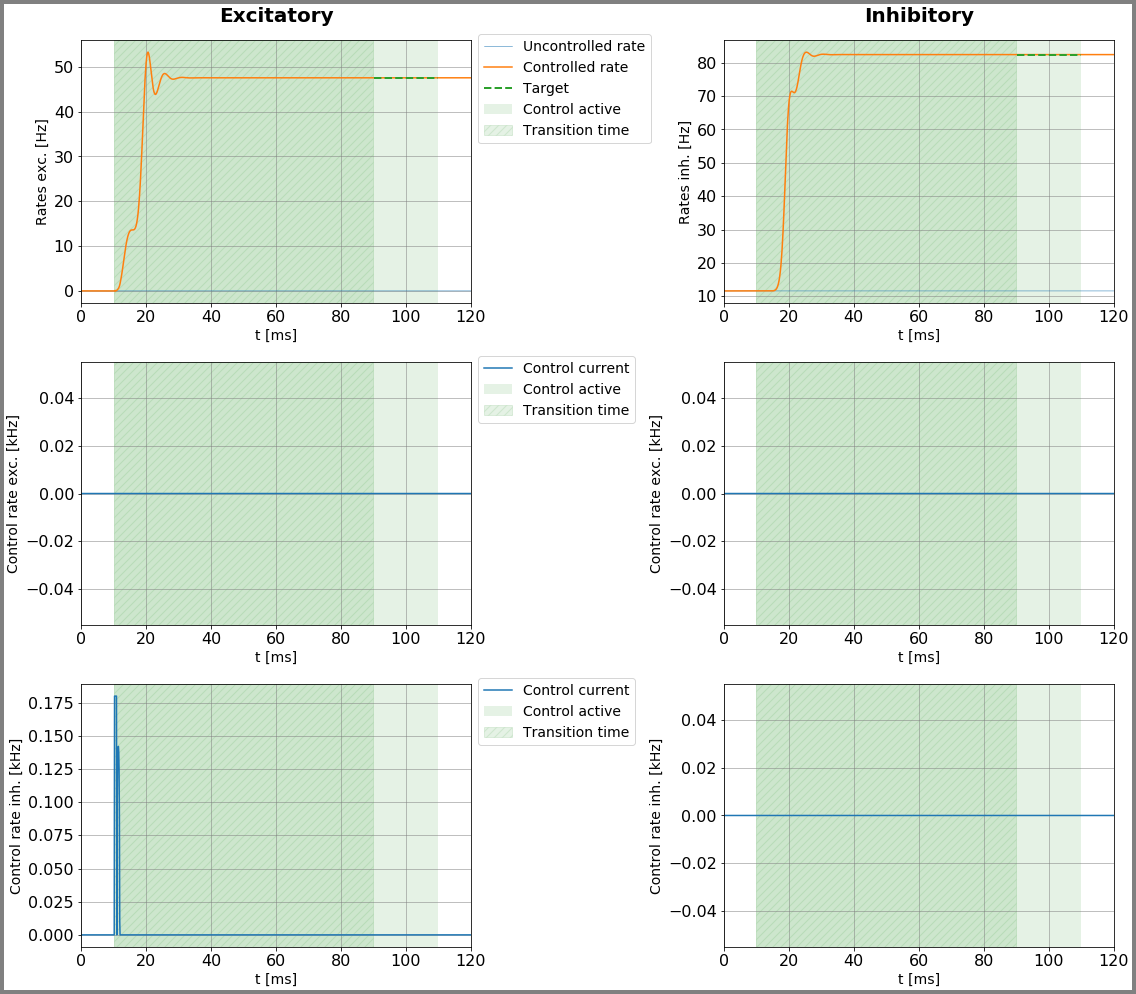

In [11]:
# A.4.a)

case_ind = 5
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  6.38604914084514
RUN  2 , total integrated cost =  5.851002598308249
RUN  3 , total integrated cost =  1.5372013276899126
RUN  4 , total integrated cost =  0.22088007147258856
RUN  5 , total integrated cost =  0.2170289653825607
RUN  6 , total integrated cost =  0.21618679703879373
RUN  7 , total integrated cost =  0.21525470689754914
RUN  8 , total integrated cost =  0.21434461972120286
RUN  9 , total integrated cost =  0.21338083632934443
RUN  10 , total integrated cost =  0.21284070603014912
RUN  11 , total integrated cost =  0.2121965883508971
RUN  12 , total integrated cost =  0.21178152279988735
RUN  13 , total integrated cost =  0.21133184591165924
RUN  14 , total integrated cost =  0.2111075709095277
RUN  15 , total integrated cost =  0.21084790244672028
RUN  16 , total integrated cost =  0.21067552212650825
RUN  17 , total integrated cost =

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  4470 , total integrated cost =  0.18316368824803958
Improved over  4470  iterations by  99.99963431764466  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7144832405180913
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.10526937387558


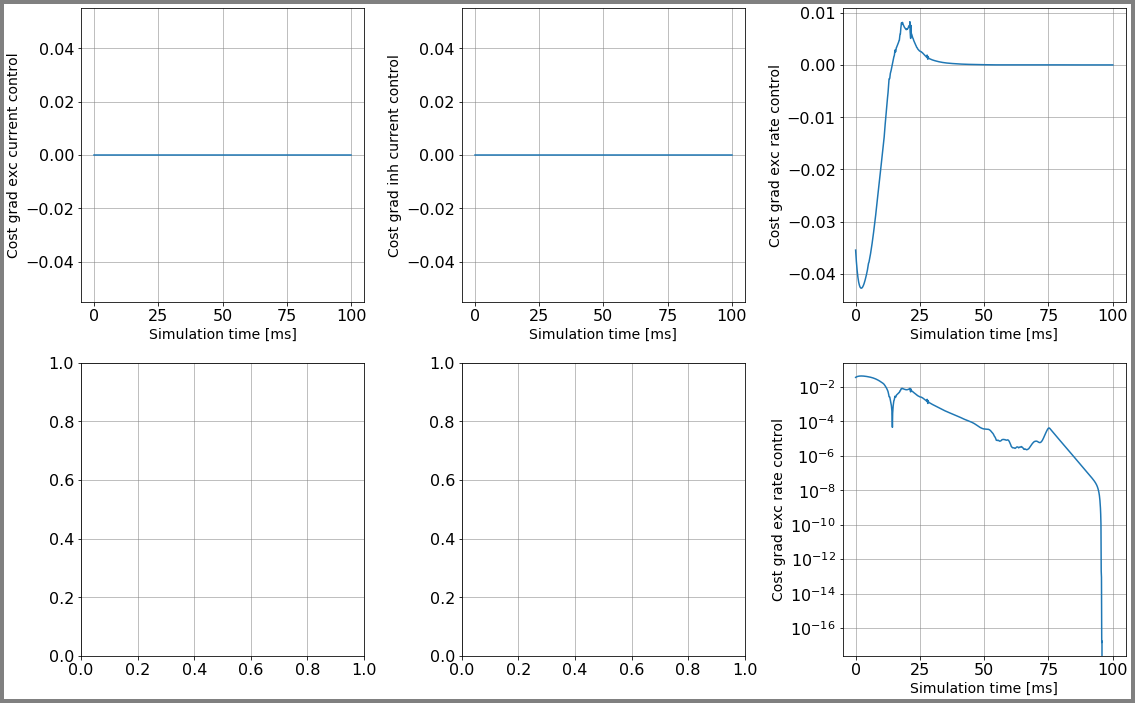

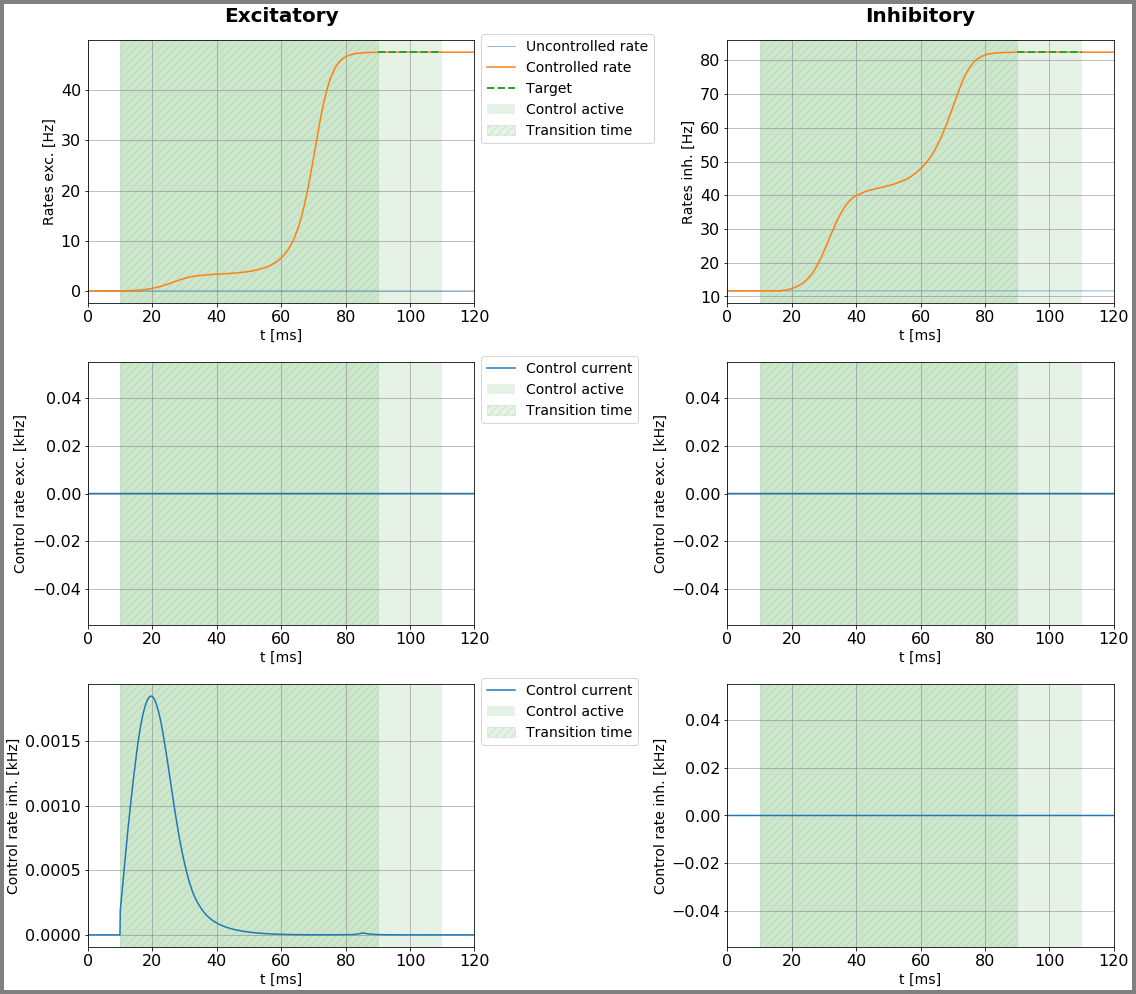

In [12]:
case_ind = 5
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 7

set cost params
control input:  [0, 1] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  26.719456554758978
RUN  2 , total integrated cost =  2.5995240988800656
RUN  3 , total integrated cost =  0.22688909700395854
RUN  4 , total integrated cost =  0.0785377572395867
RUN  5 , total integrated cost =  0.04325081743342291
RUN  6 , total integrated cost =  0.02729857141020056
RUN  7 , total integrated cost =  0.019152502525894104
RUN  8 , total integrated cost =  0.013769539123881088
RUN  9 , total integrated cost =  0.01045543621405164
RUN  10 , total integrated cost =  0.008234925649225006
RUN  11 , total integrated cost =  0.006665303744181835
RUN  12 , total integrated cost =  0.005361818051432372
RUN  13 , total integrated cost =  0.004338457488172935
RUN  14 , total integrated cost =  0.003426606838225805
RUN  15 , total integrated cost =  0.0027908734293941653
RUN  16 , total integrat

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1537 , total integrated cost =  6.539088924430444e-26
Improved over  1537  iterations by  100.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.17847913608831 -56.17834078979032


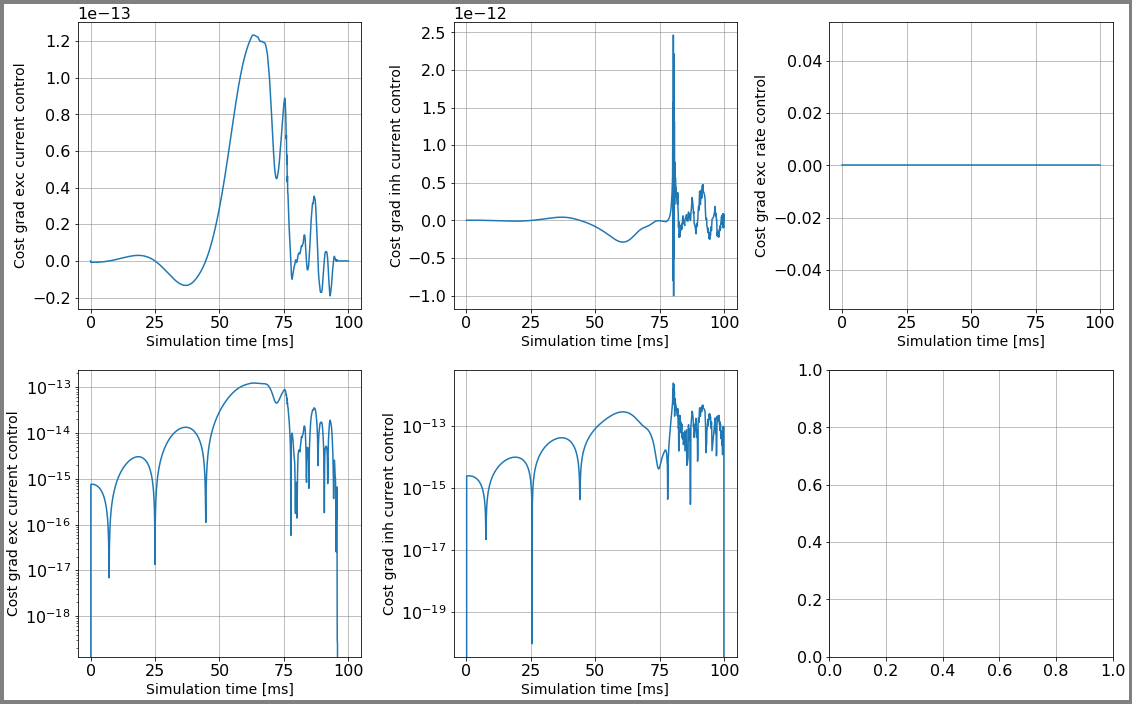

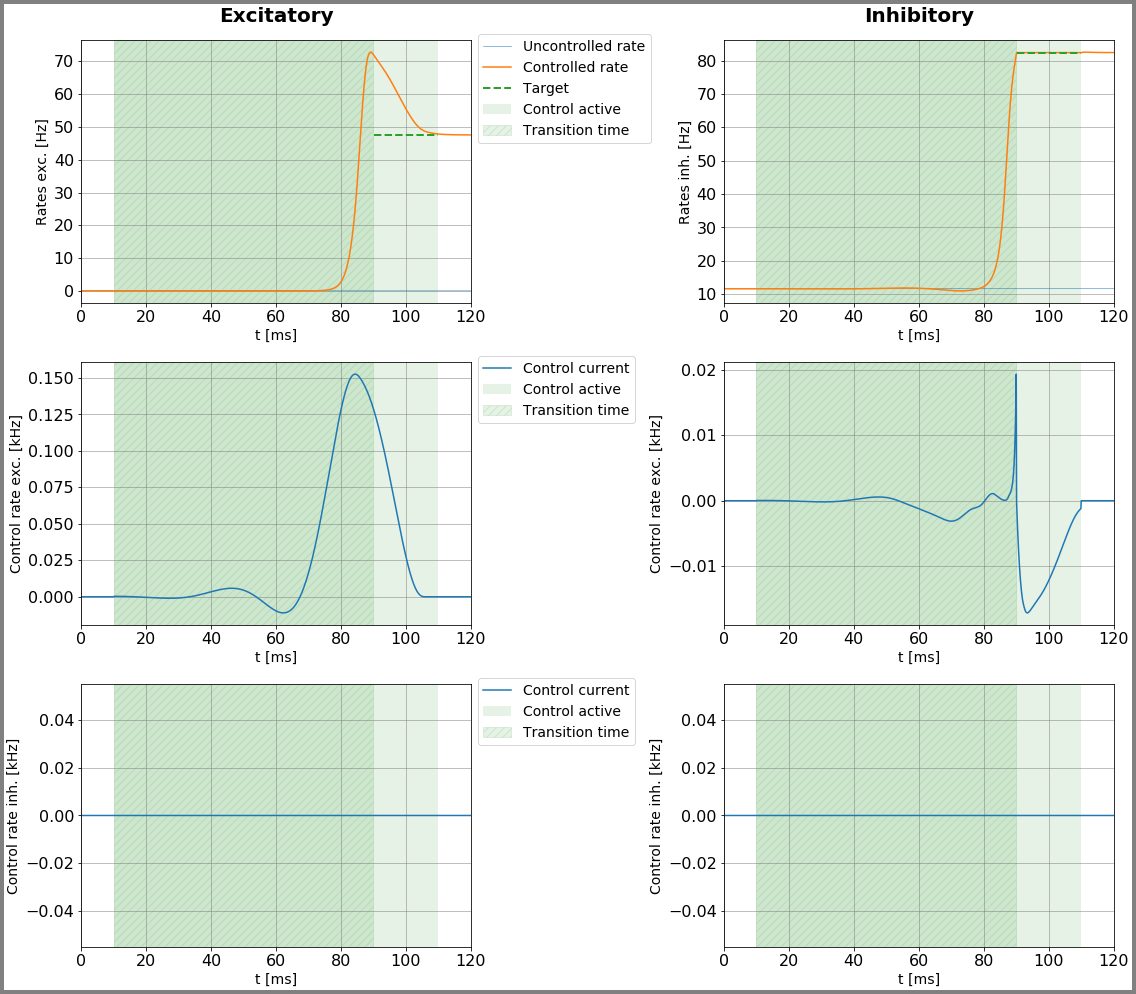

In [13]:
# A.6.a)
case_ind = 7
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  224.8994790781823
RUN  2 , total integrated cost =  206.1522380311315
RUN  3 , total integrated cost =  175.97479857172803
RUN  4 , total integrated cost =  162.76160466137696
RUN  5 , total integrated cost =  142.02259389508208
RUN  6 , total integrated cost =  130.79319838810466
RUN  7 , total integrated cost =  116.22757624235118
RUN  8 , total integrated cost =  107.89979656560854
RUN  9 , total integrated cost =  95.4829533823692
RUN  10 , total integrated cost =  88.00368653443653
RUN  11 , total integrated cost =  79.95020441715928
RUN  12 , total integrated cost =  74.8313172743506
RUN  13 , total integrated cost =  68.27130889904018
RUN  14 , total integrated cost =  63.77911134992321
RUN  15 , total integrated cost =  59.15640325906061
RUN  16 , total integrated cost =  56.34590456989011
RUN  17 , total integrated cost =  52.07047680168630

ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  14.829431353797709
RUN  5000 , total integrated cost =  14.829431353797709
Improved over  5000  iterations by  99.97039335996313  percent.
Problem in initial value trasfer:  Vmean_exc -56.17458157122494 -56.174581897313615


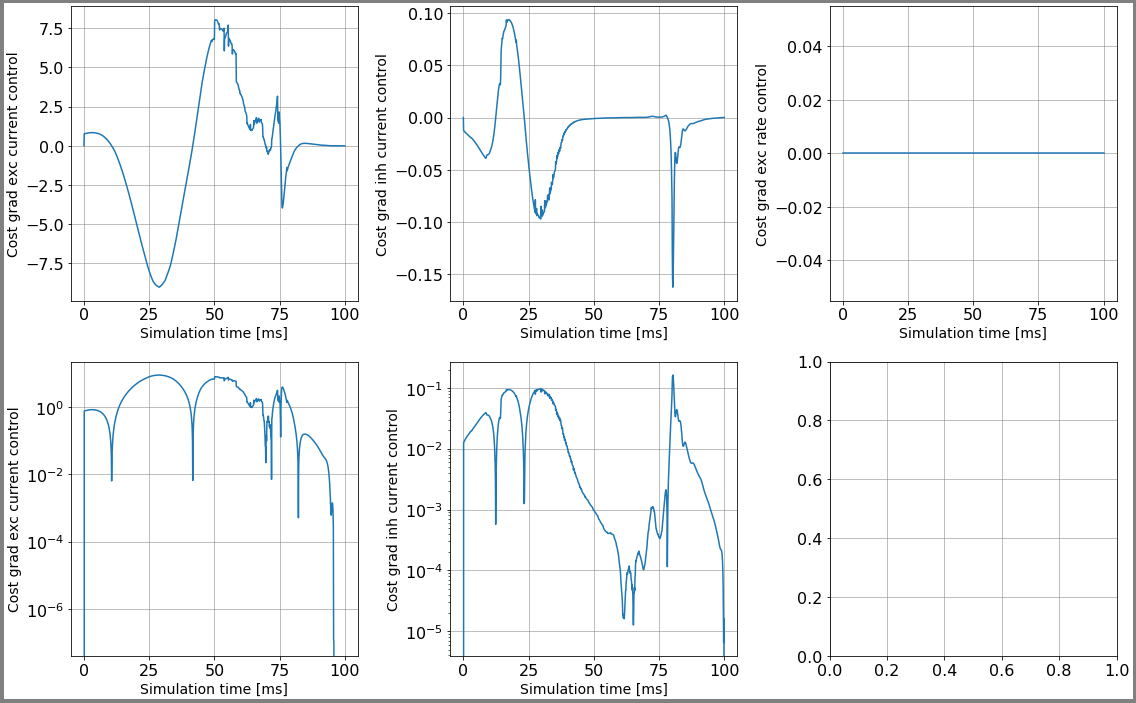

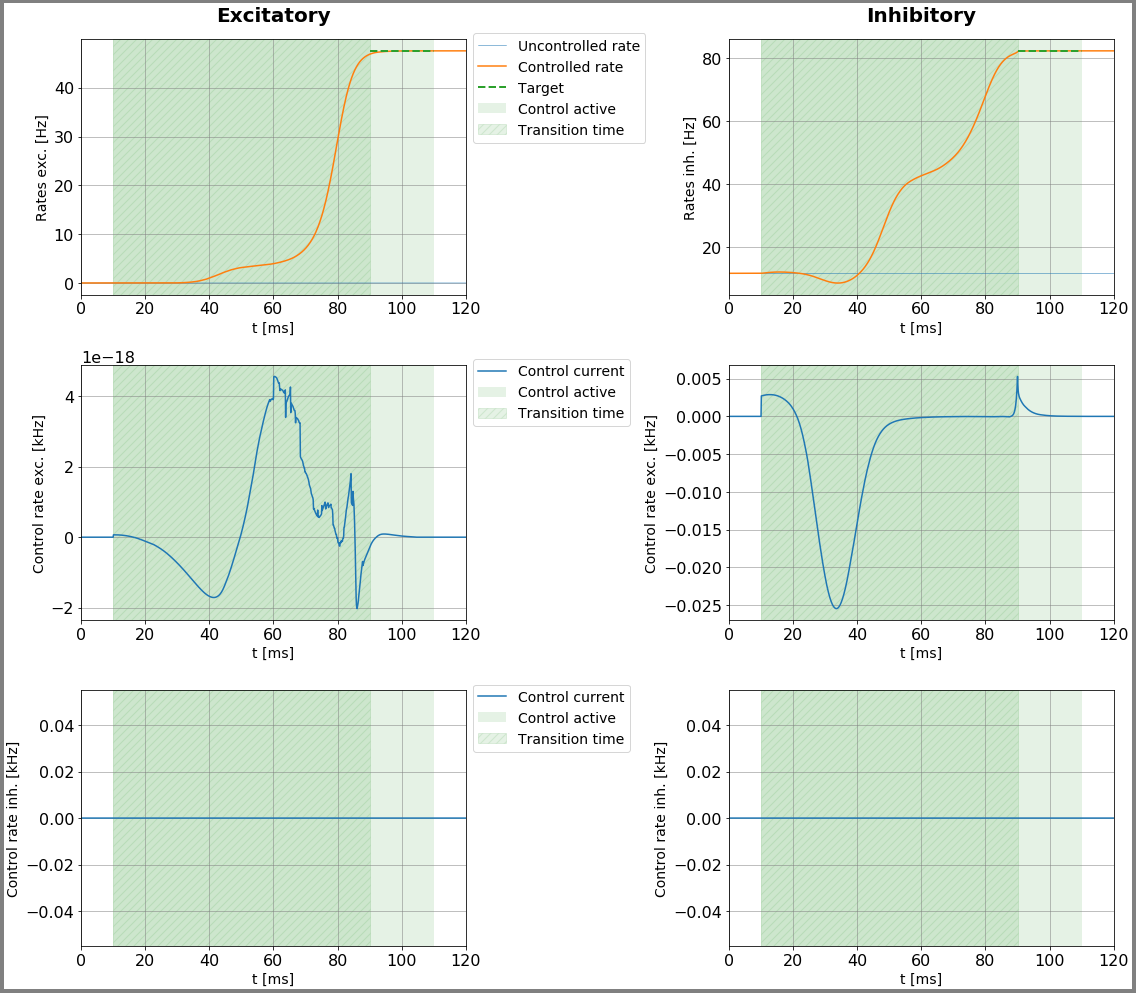

In [14]:
case_ind = 7
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 9

set cost params
control input:  [0, 2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  3.031024186152988
RUN  2 , total integrated cost =  0.6277999244281951
RUN  3 , total integrated cost =  0.00022455396128151232
RUN  4 , total integrated cost =  1.016598951447004e-07
RUN  5 , total integrated cost =  3.842831545759916e-11
RUN  6 , total integrated cost =  1.8443773619955997e-13
RUN  7 , total integrated cost =  8.956748574818431e-17
RUN  8 , total integrated cost =  4.416969685911806e-19
RUN  9 , total integrated cost =  3.924584164677787e-22
RUN  10 , total integrated cost =  5.602668368335332e-23
RUN  11 , total integrated cost =  2.122627038961332e-23
RUN  12 , total integrated cost =  1.1529597191346473e-23
RUN  13 , total integrated cost =  7.830760935397223e-24
RUN  14 , total integrated cost =  5.14169693038958e-24
RUN  15 , total integrated cost =  3.944344915783389e-24
RUN  

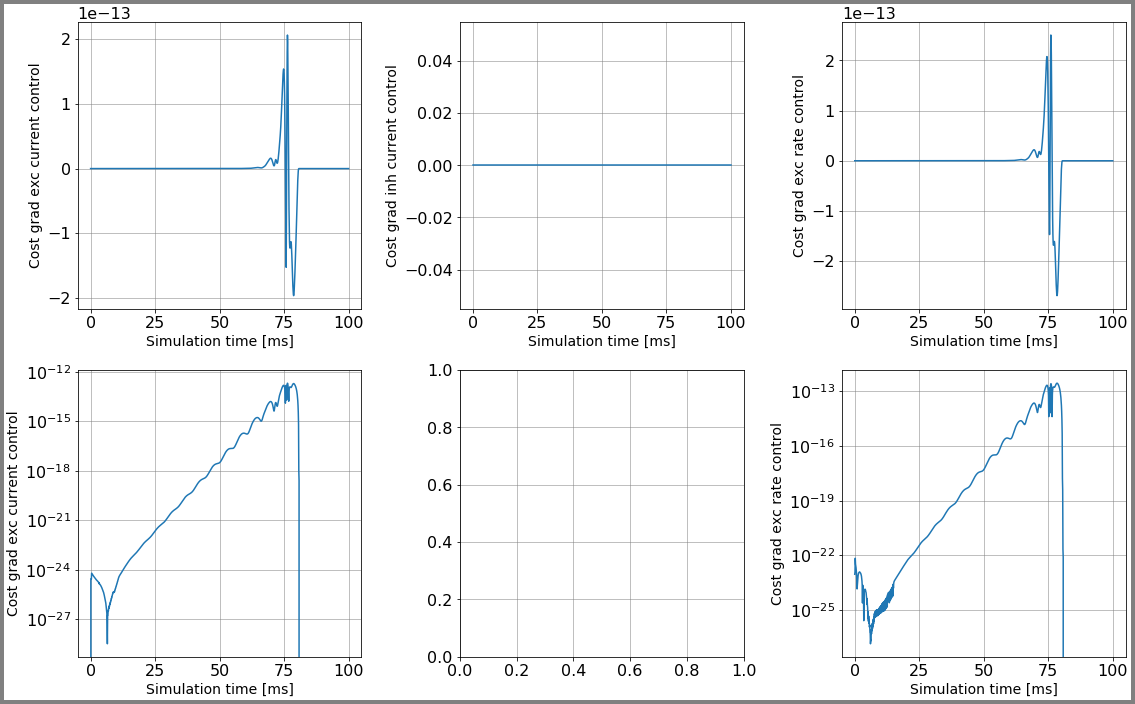

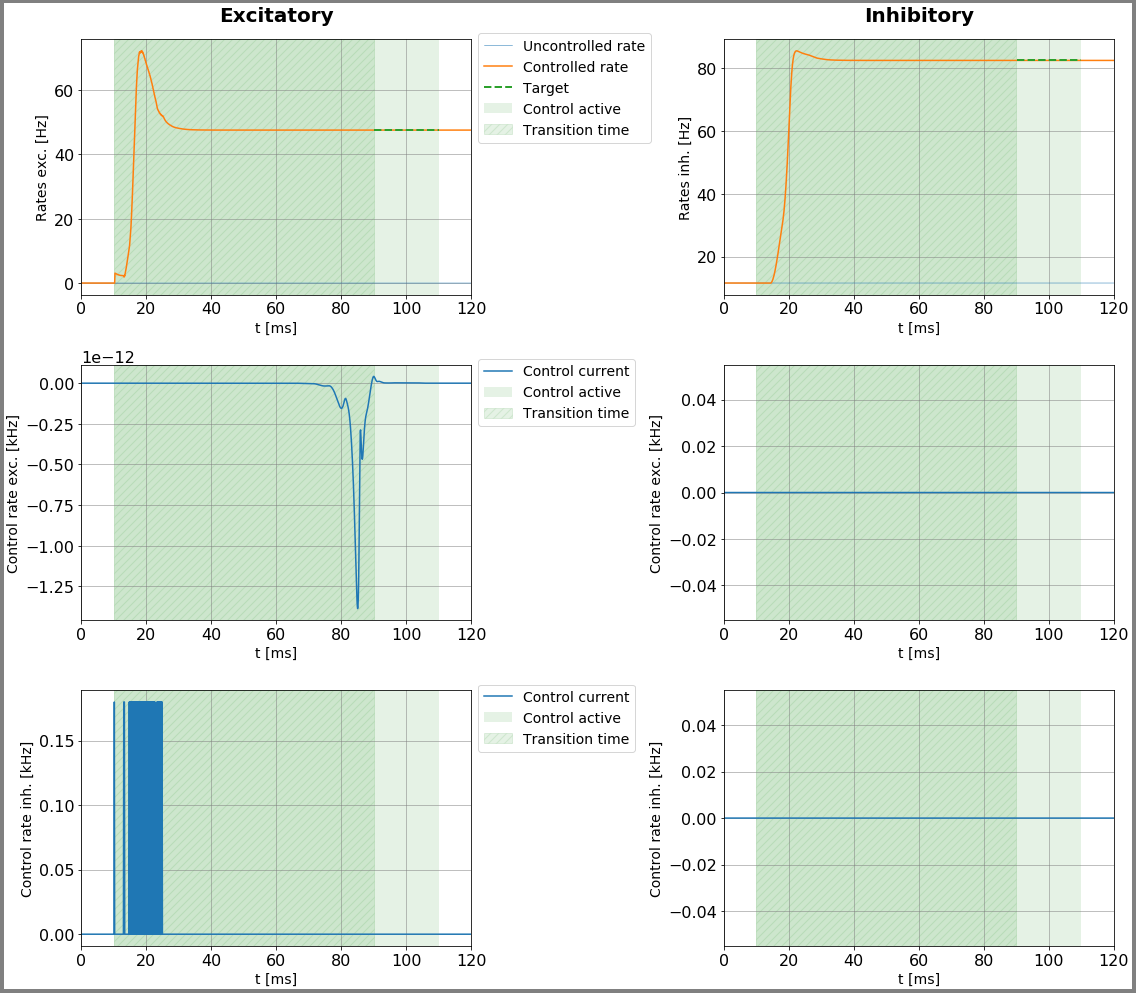

In [15]:
# A.8.a)
case_ind = 9
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  6.38604914084514
RUN  2 , total integrated cost =  5.851002598308249
RUN  3 , total integrated cost =  1.5372013276899126
RUN  4 , total integrated cost =  0.22088007147258856
RUN  5 , total integrated cost =  0.2170289653825607
RUN  6 , total integrated cost =  0.21618679703879373
RUN  7 , total integrated cost =  0.21525470689754914
RUN  8 , total integrated cost =  0.21434461972120286
RUN  9 , total integrated cost =  0.21338083632934443
RUN  10 , total integrated cost =  0.21284070603014912
RUN  11 , total integrated cost =  0.2121965883508971
RUN  12 , total integrated cost =  0.21178152279988735
RUN  13 , total integrated cost =  0.21133184591165924
RUN  14 , total integrated cost =  0.2111075709095277
RUN  15 , total integrated cost =  0.21084790244672028
RUN  16 , total integrated cost =  0.21067552212650825
RUN  17 , total integrated cost =

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  4471 , total integrated cost =  0.1831636882480395
Improved over  4471  iterations by  99.99963431764466  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.714483240519084
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.105269373841466


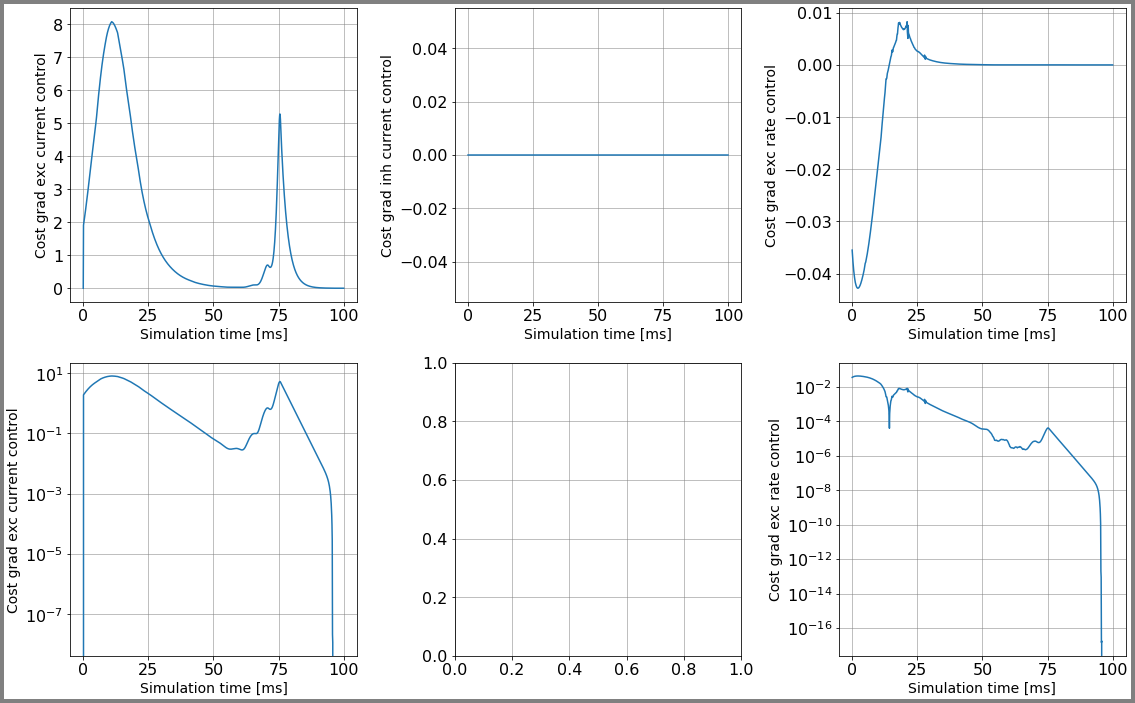

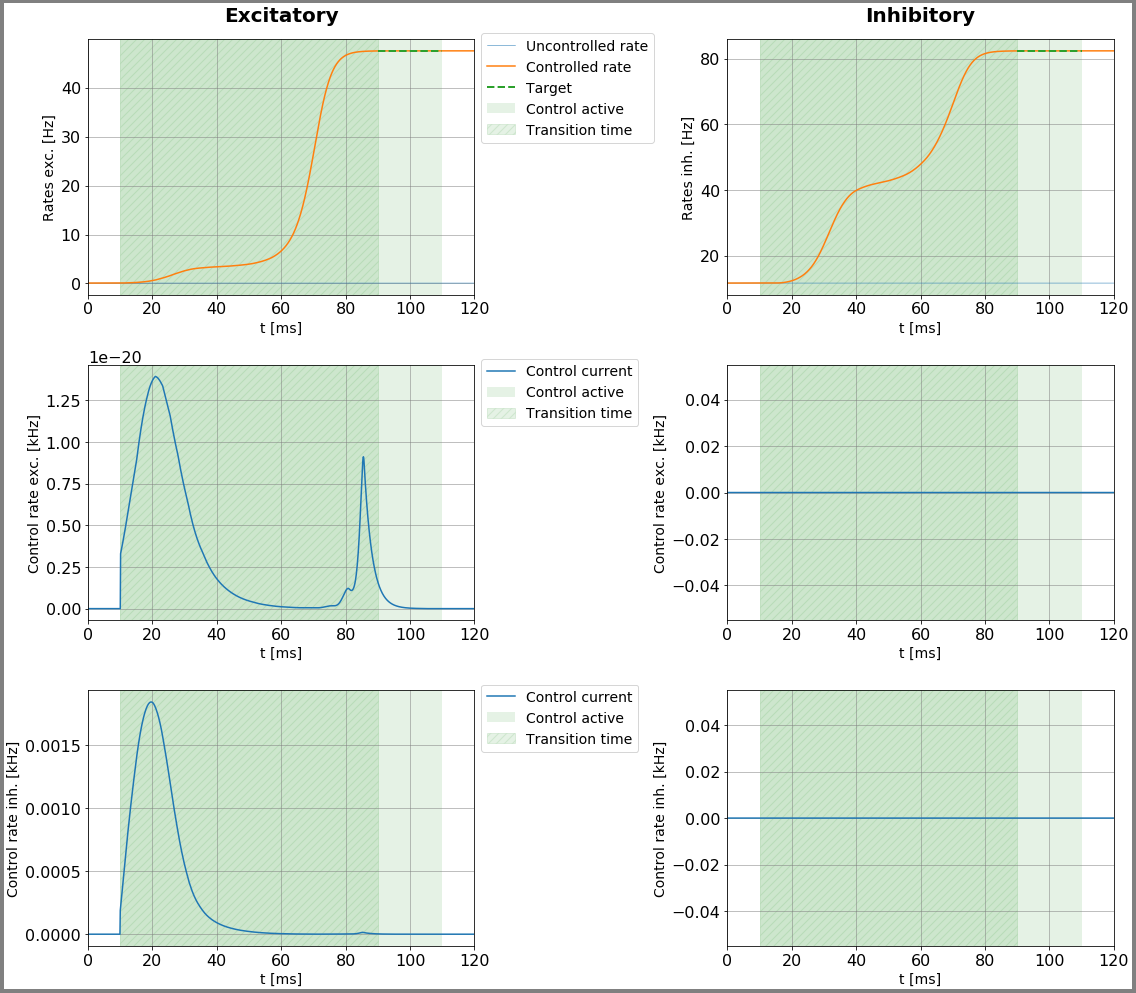

In [16]:
case_ind = 9
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 11

set cost params
control input:  [1, 2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  0.47227215999705324
RUN  2 , total integrated cost =  0.0008318248740095184
RUN  3 , total integrated cost =  1.490534195772155e-06
RUN  4 , total integrated cost =  1.419968864697198e-07
RUN  5 , total integrated cost =  4.952364597008646e-08
RUN  6 , total integrated cost =  2.8864316384428832e-08
RUN  7 , total integrated cost =  1.962527638997632e-08
RUN  8 , total integrated cost =  1.4061388040992357e-08
RUN  9 , total integrated cost =  1.0352637702222661e-08
RUN  10 , total integrated cost =  7.917919906511375e-09
RUN  11 , total integrated cost =  6.225459560542222e-09
RUN  12 , total integrated cost =  4.9808061245610615e-09
RUN  13 , total integrated cost =  4.053706308025377e-09
RUN  14 , total integrated cost =  3.3563576129078017e-09
RUN  15 , total integrated cost =  2.7833770360071963e

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  588 , total integrated cost =  4.778098948487477e-26
Improved over  588  iterations by  100.0  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.714629773010627
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.100233917332766


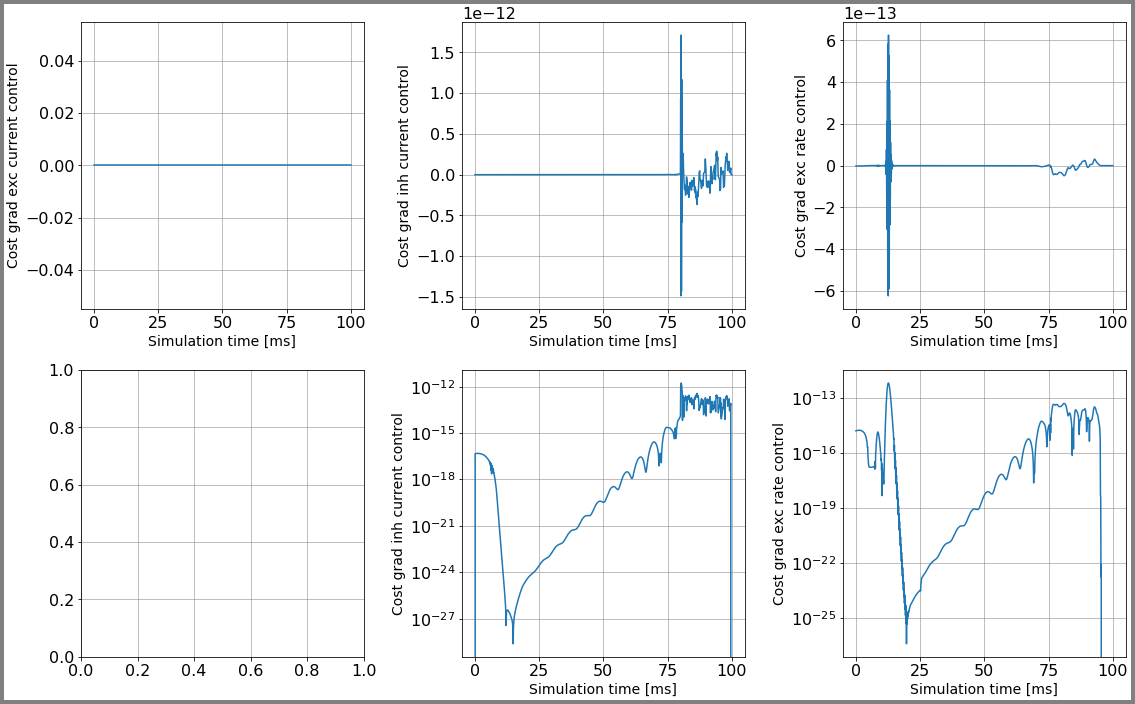

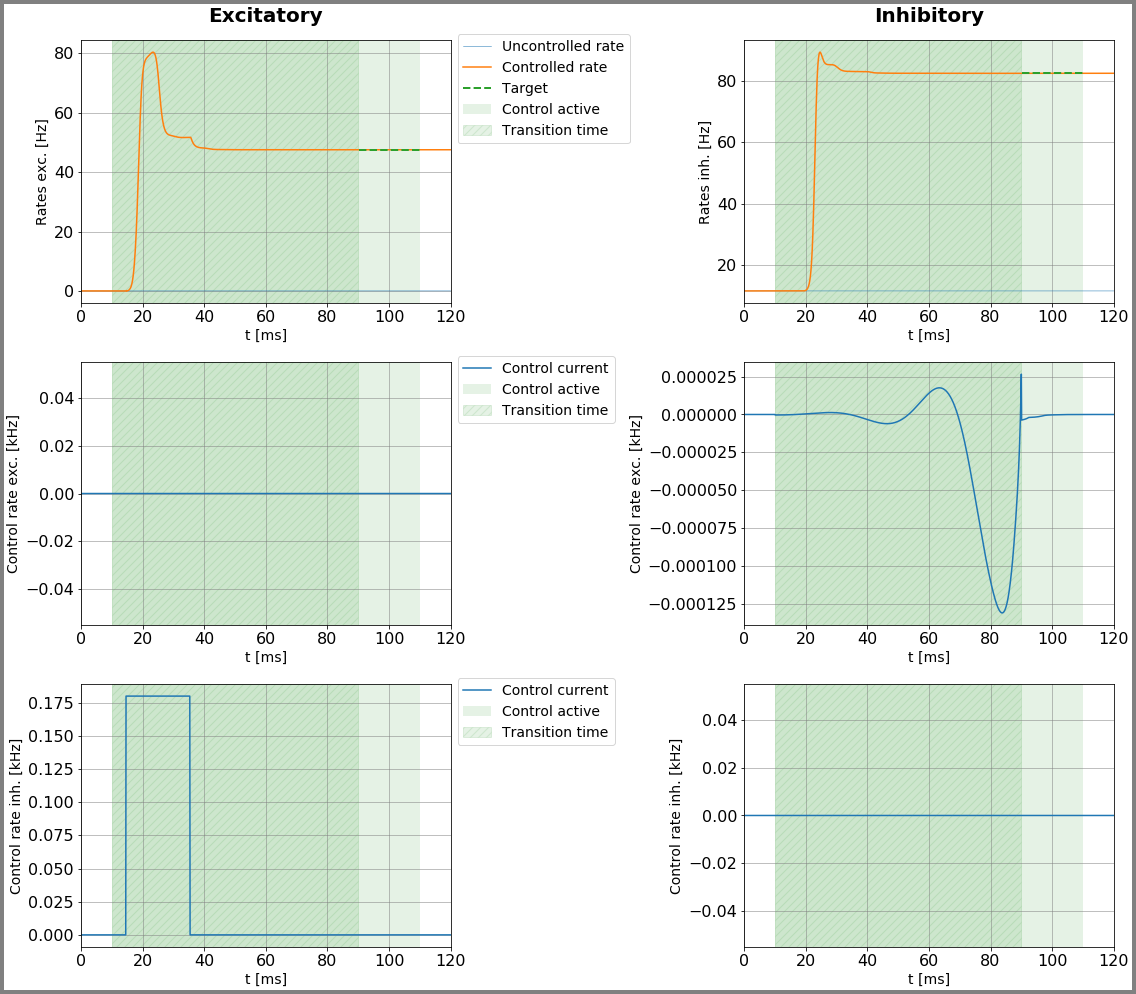

In [17]:
# A.10.a)
case_ind = 11
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  6.38604914084514
RUN  2 , total integrated cost =  5.851002598308249
RUN  3 , total integrated cost =  1.5372013276899126
RUN  4 , total integrated cost =  0.22088007147258856
RUN  5 , total integrated cost =  0.2170289653825607
RUN  6 , total integrated cost =  0.21618679703879373
RUN  7 , total integrated cost =  0.21525470689754914
RUN  8 , total integrated cost =  0.21434461972120286
RUN  9 , total integrated cost =  0.21338083632934443
RUN  10 , total integrated cost =  0.21284070603014912
RUN  11 , total integrated cost =  0.2121965883508971
RUN  12 , total integrated cost =  0.21178152279988735
RUN  13 , total integrated cost =  0.21133184591165924
RUN  14 , total integrated cost =  0.2111075709095277
RUN  15 , total integrated cost =  0.21084790244672028
RUN  16 , total integrated cost =  0.21067552212650825
RUN  17 , total integrated cost =

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  4470 , total integrated cost =  0.18316368824803958
Improved over  4470  iterations by  99.99963431764466  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7144832405180913
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.10526937387558


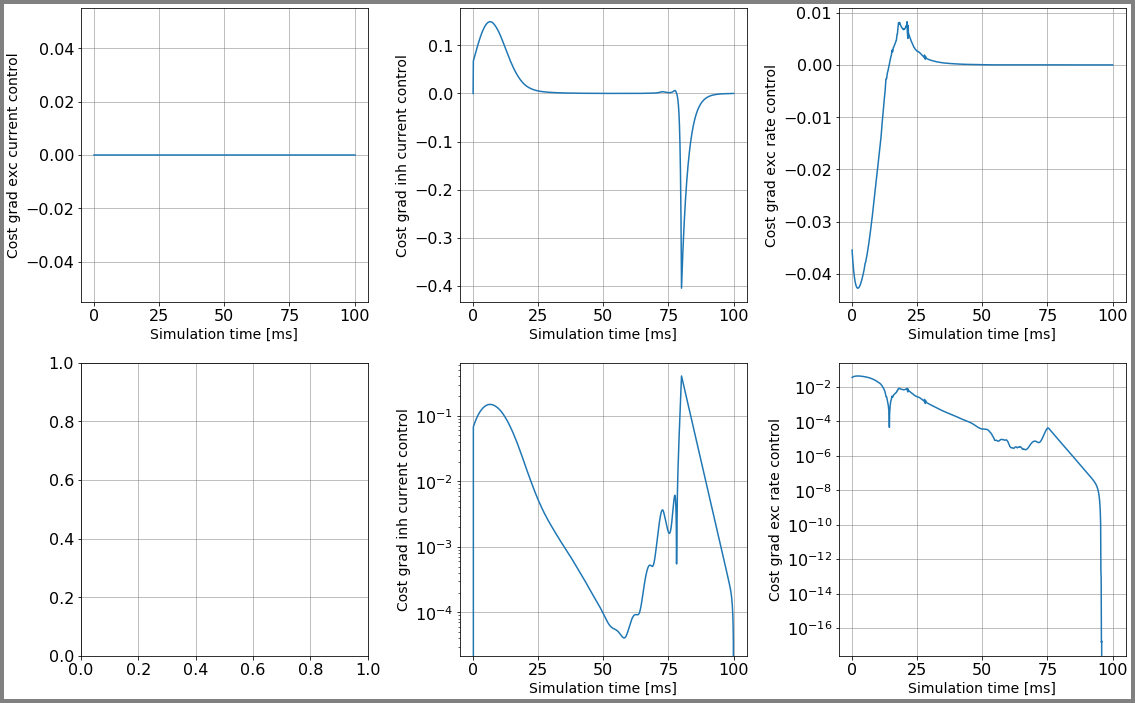

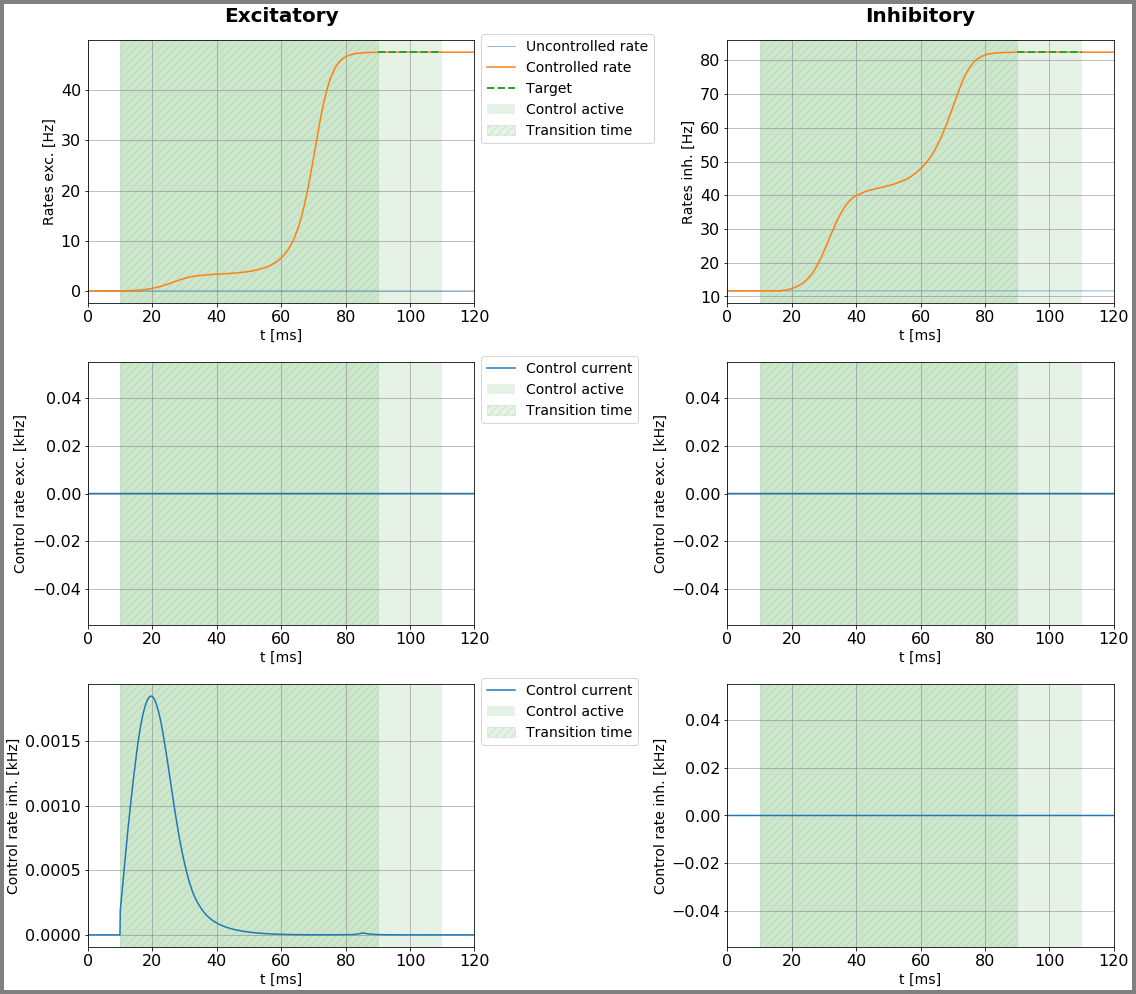

In [18]:
case_ind = 11
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 13

set cost params
control input:  [0, 1, 2] , precision measure:  [1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  0.44346370185999656
RUN  2 , total integrated cost =  7.19002218268901e-11
RUN  3 , total integrated cost =  9.469802527060796e-15
RUN  4 , total integrated cost =  3.628573529916018e-16
RUN  5 , total integrated cost =  1.3289355353261355e-16
RUN  6 , total integrated cost =  8.479856936432174e-17
RUN  7 , total integrated cost =  6.008786533807201e-17
RUN  8 , total integrated cost =  4.4392184058586196e-17
RUN  9 , total integrated cost =  3.370265303365141e-17
RUN  10 , total integrated cost =  2.666186886558786e-17
RUN  11 , total integrated cost =  2.140826184618665e-17
RUN  12 , total integrated cost =  1.7377309393135606e-17
RUN  13 , total integrated cost =  1.4367883056884624e-17
RUN  14 , total integrated cost =  1.195162501346056e-17
RUN  15 , total integrated cost =  1.0008108712379146

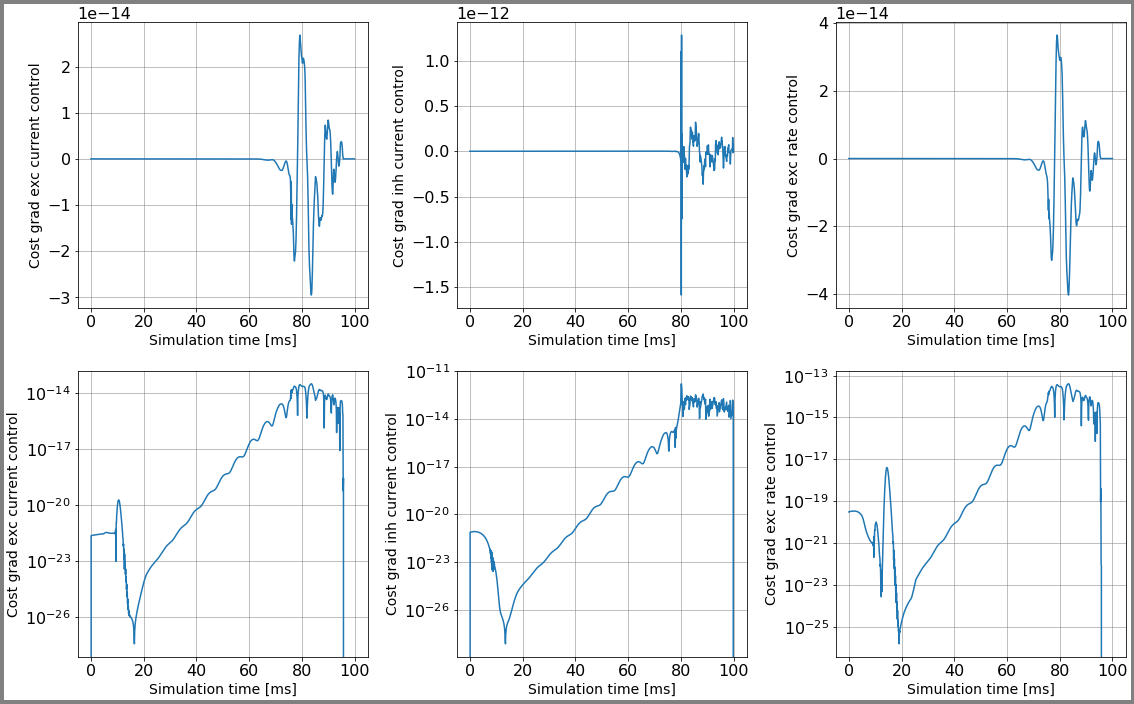

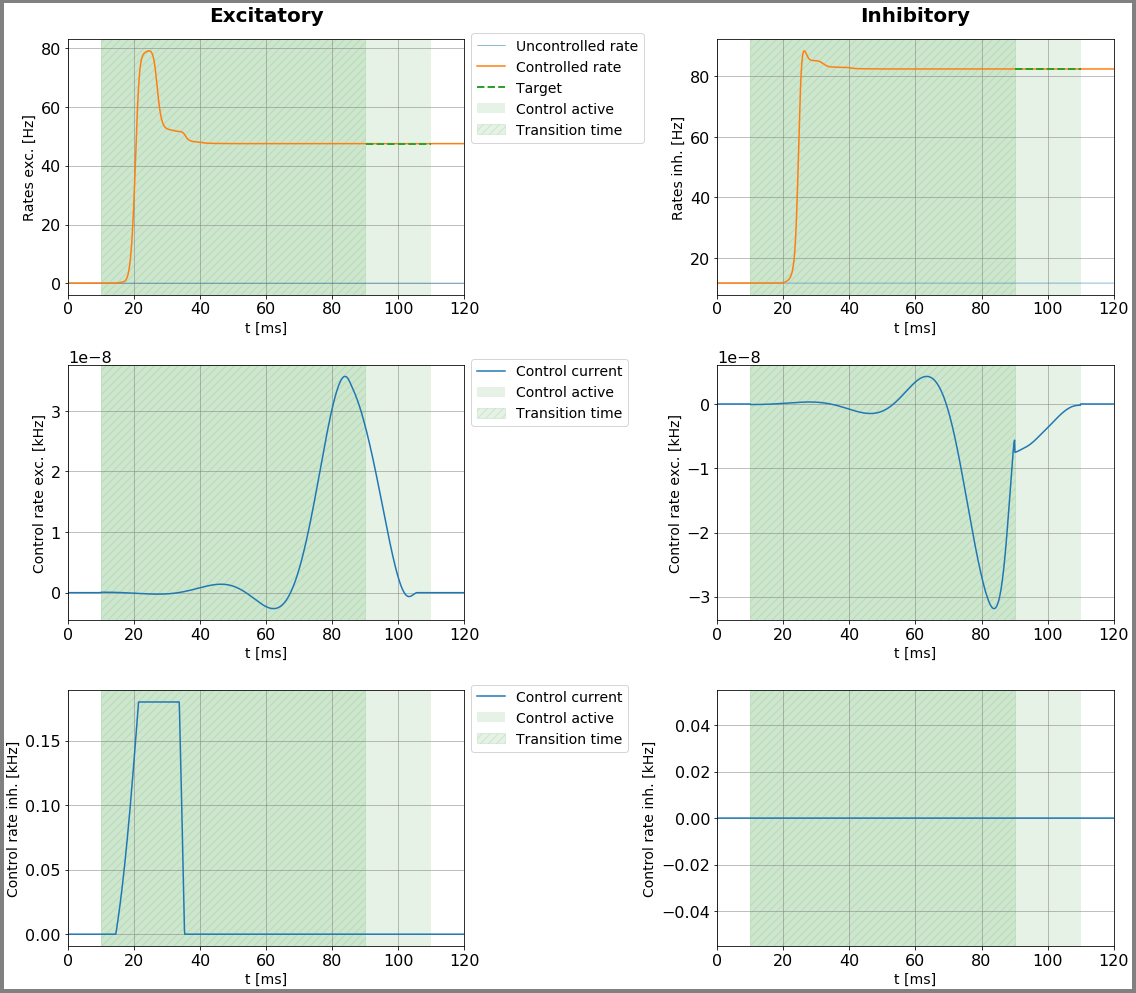

In [19]:
# A.12.a)
case_ind = 13
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  50088.1941866105
RUN  1 , total integrated cost =  6.38604914084514
RUN  2 , total integrated cost =  5.851002598308249
RUN  3 , total integrated cost =  1.5372013276899126
RUN  4 , total integrated cost =  0.22088007147258856
RUN  5 , total integrated cost =  0.2170289653825607
RUN  6 , total integrated cost =  0.21618679703879373
RUN  7 , total integrated cost =  0.21525470689754914
RUN  8 , total integrated cost =  0.21434461972120286
RUN  9 , total integrated cost =  0.21338083632934443
RUN  10 , total integrated cost =  0.21284070603014912
RUN  11 , total integrated cost =  0.2121965883508971
RUN  12 , total integrated cost =  0.21178152279988735
RUN  13 , total integrated cost =  0.21133184591165924
RUN  14 , total integrated cost =  0.2111075709095277
RUN  15 , total integrated cost =  0.21084790244672028
RUN  16 , total integrated cost =  0.21067552212650825
RUN  17 , total integrated cost =

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  4470 , total integrated cost =  0.18316368824803958
Improved over  4470  iterations by  99.99963431764466  percent.
Problem in initial value trasfer:  sigmae_f 0.714629799422801 0.7144832405180913
Problem in initial value trasfer:  tau_exc 27.1002330097023 27.10526937387558


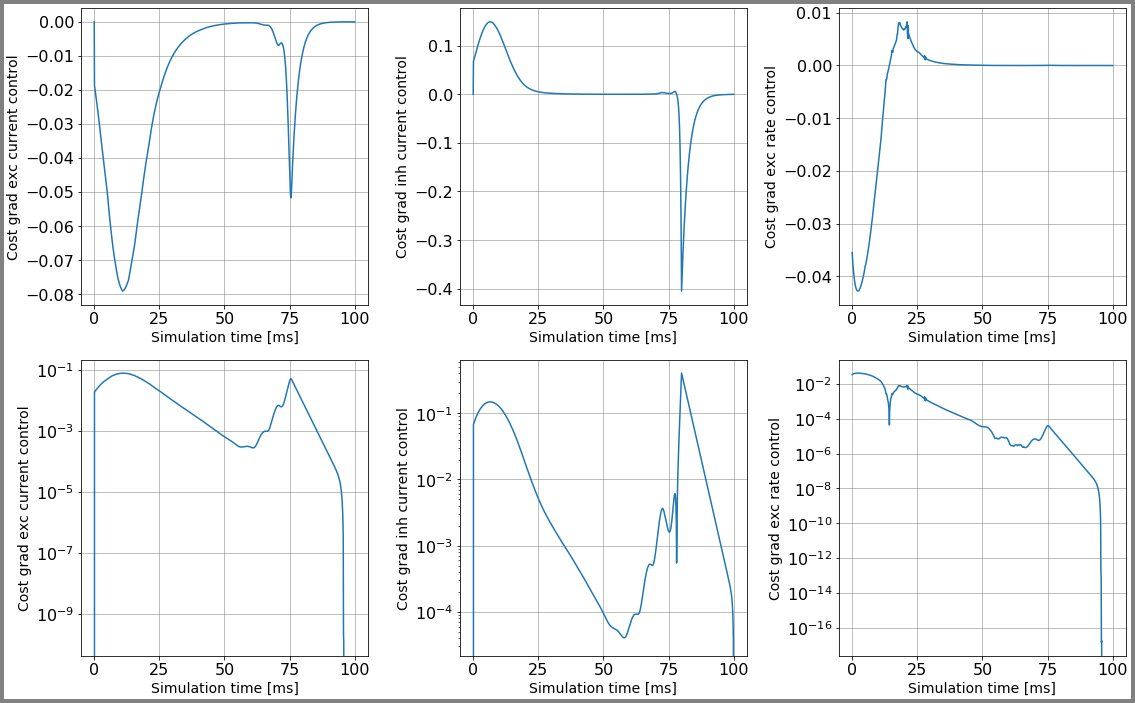

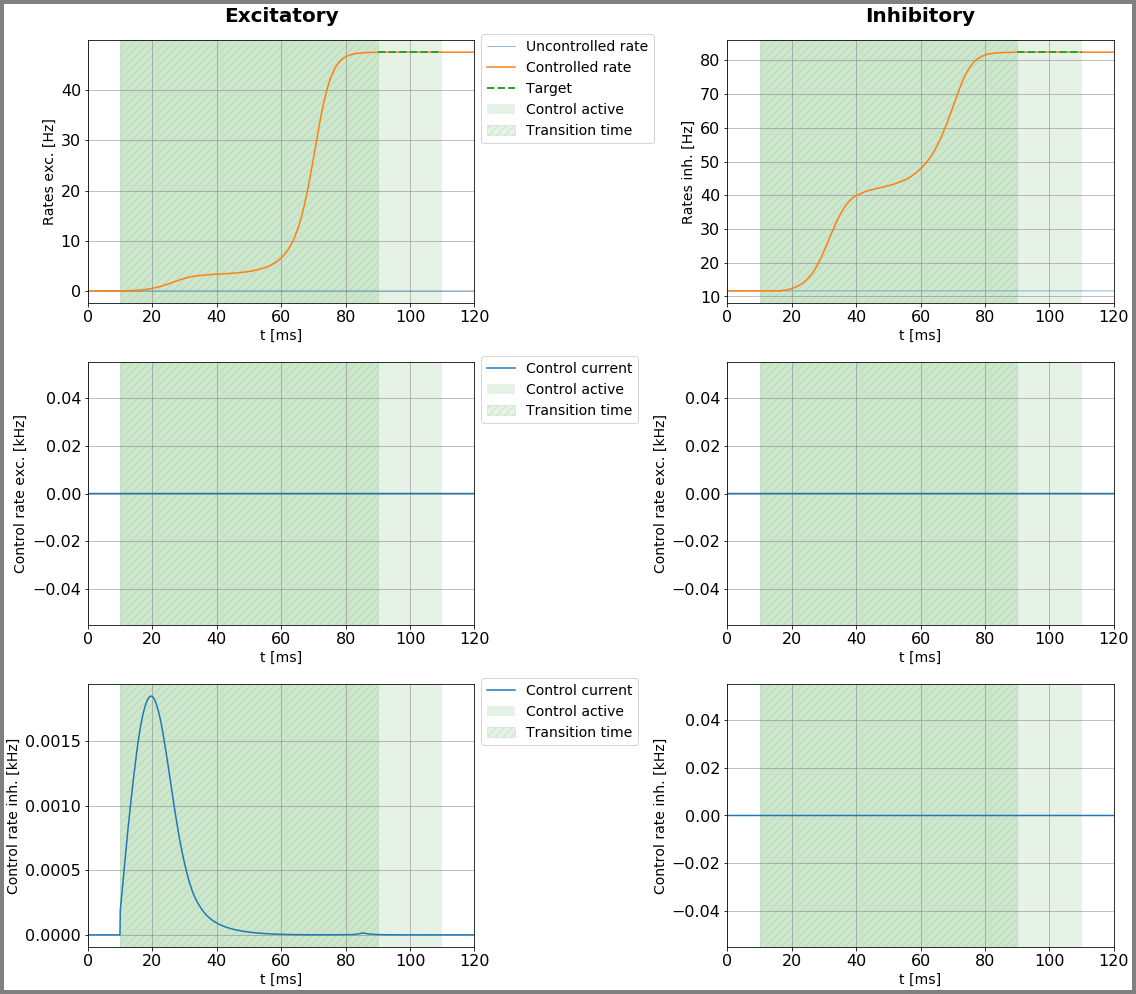

In [20]:
case_ind = 13
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )